In [1]:
import os.path
from datasets import load_dataset, Image, DatasetDict
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, regularizers

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from pprint import pprint

# Data loading

The used dataset is a custom dataset. Where pictures of different fruits where manually taken. Except for deleting image files's metadata, no other preprocessing where done on this dataset.

There are 3 possible issues to bear in mind:
1. Between the `Apple` instances, there are red and green apples mixed.
2. All the pictures has a size of 4032x3024px
3. A good quality dataset normally take pictures of different individuals, so we can ensure that the same individual doesn´t appear in different data splits and influate the results. However, since that could take a long time and effort, the pictures has been done from the same individuals.


In [2]:
_data_path = os.path.join("dataset", "Fruits")

dataset = load_dataset("imagefolder", data_dir=_data_path)

dataset = dataset.cast_column("image", Image(mode="RGB")) # Standarize the RGB format

Resolving data files:   0%|          | 0/286 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 286
    })
})

In [4]:
target_ids = dataset["train"].unique("label")
target_ids

[0, 1, 2, 3, 4]

In [5]:
def id2label(id):
    return dataset["train"].features["label"].int2str(id)

In [6]:
target_labels = [id2label(id) for id in target_ids]
target_labels

['Apple', 'Banana', 'Lemon', 'Orange', 'Pear']

# Data analisis

In [7]:
def show_image(image):
  plt.imshow(image)
  plt.axis("off")
  plt.show()

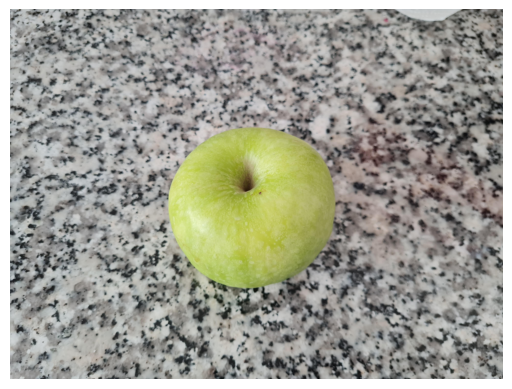

In [8]:
show_image(dataset["train"][0]["image"])

In [9]:
Counter(dataset["train"]["label"])

Counter({0: 51, 1: 58, 2: 62, 3: 58, 4: 57})

As we can see, the classes are pretty balanced and the pictures taken are high definition. However, an AI model like a CNN normally doesn't need that much definition to work properly, and also in would increase the training and inference time by a lot.

# Data egineering

In [10]:
RANDOM_SEED = 42
VAL_SIZE = 0.2
TEST_SIZE = 0.2
IMAGE_SIZE = 64

In [11]:
def standarize_image(data):
    image_tensor = tf.convert_to_tensor(data["image"])
    image_tensor = tf.image.resize(image_tensor, [IMAGE_SIZE, IMAGE_SIZE]) # Resize image
    image_tensor = tf.cast(image_tensor, tf.float32) / 127.5 - 1 # Normalize value ranges
    data["image"] = image_tensor
    return data

In [12]:
def train_val_test_split(shuffle):
    test_split = dataset["train"].train_test_split(
        test_size=TEST_SIZE,
        shuffle=shuffle,
        seed=RANDOM_SEED
        )

    train_val_split = test_split["train"].train_test_split(
        test_size=VAL_SIZE,
        shuffle=shuffle,
        seed=RANDOM_SEED
        )

    result_dataset = DatasetDict({
        "train": train_val_split["train"],
        "validation": train_val_split["test"],
        "test": test_split["test"]
    })

    return result_dataset

dataset = train_val_test_split(True)

dataset = dataset.map(
    standarize_image,
    batched=False,
    writer_batch_size=60,
)

dataset

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 182
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 46
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 58
    })
})

The AI model will be train with 64x64px images. Which is a decent resoluting without big training times.

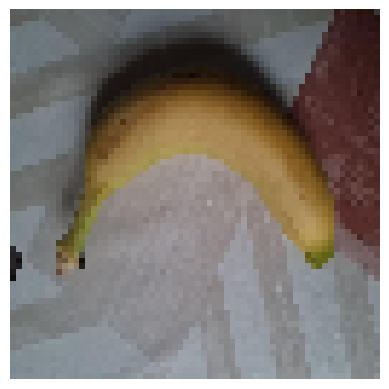

In [13]:
show_image((tf.cast(dataset["train"][0]["image"], tf.float32) + 1) / 2) # show 64x64px image

# Base model training

A CNN model will be train. This first model will serve as a prototipe to be observed and help to make the right decisions to improve it and make a better one.

In [14]:
base_model = tf.keras.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    # Tensorflow data augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.5, fill_mode="reflect"),

    # Convoluational layers
    layers.Conv2D(filters=20, kernel_size=(3, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=15, kernel_size=(3, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    # Dense layers
    layers.Dense(units=30, activation="relu"),
    layers.Dropout(rate=0.25),
    layers.Dense(units=20, activation="relu"),
    layers.Dropout(rate=0.25),
    layers.Dense(units=len(target_ids), activation="softmax")
])

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
)

In [15]:
_TRAIN_DATA_BATCH = 40
_VAL_DATA_BATCH = 30

_train_data = dataset["train"].to_tf_dataset(
            batch_size=_TRAIN_DATA_BATCH,
            columns=["image"],
            label_cols=["label"],
        )

_val_data = dataset["validation"].to_tf_dataset(
            batch_size=_VAL_DATA_BATCH,
            columns=["image"],
            label_cols=["label"],
        )

base_model.fit(
    x=_train_data,
    batch_size=_TRAIN_DATA_BATCH,
    epochs=30,
    validation_data=_val_data,
    validation_batch_size=_VAL_DATA_BATCH,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 649ms/step - accuracy: 0.2143 - loss: 1.6310 - val_accuracy: 0.2391 - val_loss: 1.5922
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2637 - loss: 1.5546 - val_accuracy: 0.4130 - val_loss: 1.5116
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3297 - loss: 1.5226 - val_accuracy: 0.4348 - val_loss: 1.4723
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3571 - loss: 1.4494 - val_accuracy: 0.3913 - val_loss: 1.3959
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3352 - loss: 1.4034 - val_accuracy: 0.4565 - val_loss: 1.3399
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4066 - loss: 1.3140 - val_accuracy: 0.6304 - val_loss: 1.3037
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4231 - loss: 1.2850 - val_accuracy: 0.5870 - val_loss: 1.2783
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4176 - loss: 1.2615 - val_accuracy: 0.5217 - val_loss: 1.2994
Epoch 9/30
5

# Base model testing

In [16]:
def ids2labels(ids):
  return [id2label(id) for id in ids]

In [17]:
def tf_preds2ids(pred_results):
  return [tf.argmax(result, axis=-1).numpy().item() for result in pred_results]

In [18]:
def _label_raw_metrics(raw_metrics):
    return {label: metric for label, metric in zip(target_labels, raw_metrics)}

def calc_test_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred, normalize=True)
    precision = precision_score(y_true=y_true, y_pred=y_pred, labels=target_labels, average=None)
    recall =  recall_score(y_true=y_true, y_pred=y_pred, labels=target_labels, average=None)
    f1 = f1_score(y_true=y_true, y_pred=y_pred, labels=target_labels, average=None)
    return {
        'accuracy': accuracy,
        'precision': _label_raw_metrics(precision),
        'recall': _label_raw_metrics(recall),
        'f1': _label_raw_metrics(f1)
    }

In [19]:
def show_confusion_matrix_plot(y_true, y_pred):
    cfs_matrix = confusion_matrix(
                 y_true=y_true,
                 y_pred=y_pred,
                 labels=target_labels
                 )
    sns.heatmap(cfs_matrix,
                annot=True,
                cmap='Blues',
                xticklabels=target_labels,
                yticklabels=target_labels
                )
    plt.ylabel('prediction')
    plt.xlabel('real')
    plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 773ms/step
{'accuracy': 0.9175824175824175,
 'f1': {'Apple': np.float64(0.8656716417910447),
        'Banana': np.float64(0.9066666666666666),
        'Lemon': np.float64(0.9882352941176471),
        'Orange': np.float64(0.958904109589041),
        'Pear': np.float64(0.84375)},
 'precision': {'Apple': np.float64(0.8787878787878788),
               'Banana': np.float64(0.85),
               'Lemon': np.float64(1.0),
               'Orange': np.float64(0.9722222222222222),
               'Pear': np.float64(0.8709677419354839)},
 'recall': {'Apple': np.float64(0.8529411764705882),
            'Banana': np.float64(0.9714285714285714),
            'Lemon': np.float64(0.9767441860465116),
            'Orange': np.float64(0.9459459459459459),
            'Pear': np.float64(0.8181818181818182)}}


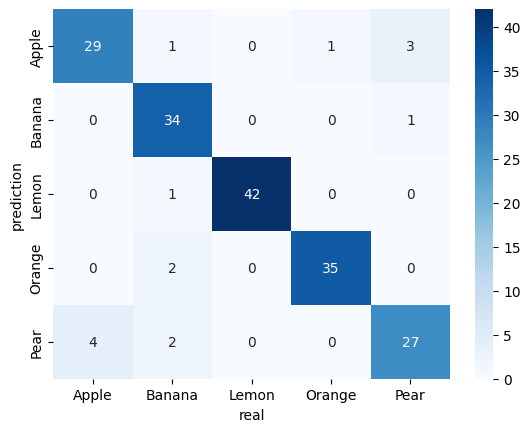

In [20]:
y_train = ids2labels(dataset["train"]["label"])
y_pred_raw = base_model.predict(
    dataset["train"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_train, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_train, y_pred=y_pred)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step
{'accuracy': 0.8260869565217391,
 'f1': {'Apple': np.float64(0.625),
        'Banana': np.float64(0.8181818181818182),
        'Lemon': np.float64(0.9473684210526315),
        'Orange': np.float64(1.0),
        'Pear': np.float64(0.6666666666666666)},
 'precision': {'Apple': np.float64(0.5555555555555556),
               'Banana': np.float64(0.9),
               'Lemon': np.float64(0.9),
               'Orange': np.float64(1.0),
               'Pear': np.float64(0.7142857142857143)},
 'recall': {'Apple': np.float64(0.7142857142857143),
            'Banana': np.float64(0.75),
            'Lemon': np.float64(1.0),
            'Orange': np.float64(1.0),
            'Pear': np.float64(0.625)}}


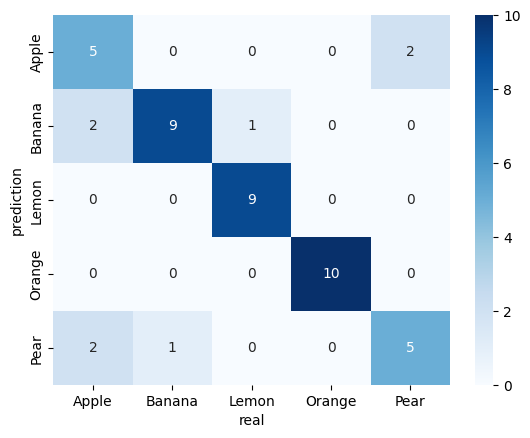

In [21]:
y_val = ids2labels(dataset["validation"]["label"])
y_pred_raw = base_model.predict(
    dataset["validation"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_val, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_val, y_pred=y_pred)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step
{'accuracy': 0.896551724137931,
 'f1': {'Apple': np.float64(0.9),
        'Banana': np.float64(0.8333333333333334),
        'Lemon': np.float64(0.9523809523809523),
        'Orange': np.float64(0.9523809523809523),
        'Pear': np.float64(0.8666666666666667)},
 'precision': {'Apple': np.float64(0.9),
               'Banana': np.float64(0.7692307692307693),
               'Lemon': np.float64(0.9090909090909091),
               'Orange': np.float64(1.0),
               'Pear': np.float64(0.9285714285714286)},
 'recall': {'Apple': np.float64(0.9),
            'Banana': np.float64(0.9090909090909091),
            'Lemon': np.float64(1.0),
            'Orange': np.float64(0.9090909090909091),
            'Pear': np.float64(0.8125)}}


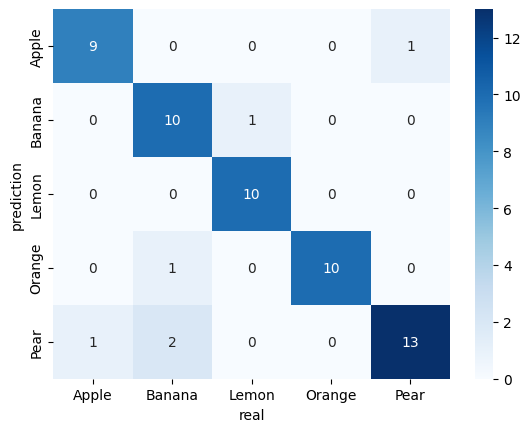

In [22]:
y_test = ids2labels(dataset["test"]["label"])
y_pred_raw = base_model.predict(
    dataset["test"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_test, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_test, y_pred=y_pred)

In general, this first model turned out to be satisfying. Even though they show evidence of overfitting, the accuracy results and confusion matrices show that this model might do a good job on an environment where support for classifying fruits is needed. However, if we take a look to the other metrics, which are more exhaustive with the model, we see that the model have problems with apples and bananas. So if the production environment depends entirely on the model for classification, it might be better to improve those metrics.

# Upgrate model training

The main problem of the previous model is that there is a big gap between validation data and other data splits, which could be indicating the presence of overfitting in the model. So for the next model, the main objective will be to reduce the gap between data splits while trying to maintain decents results.

In [130]:
upgrated_model = tf.keras.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    # Tensorflow data augmentation
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.5, fill_mode="reflect"),

    # Convoluational layers
    layers.Conv2D(filters=20, kernel_size=(7, 7), activation="relu"),
    layers.SpatialDropout2D(rate=0.15),
    layers.MaxPooling2D(pool_size=(4, 4)),

    layers.Conv2D(filters=15, kernel_size=(10, 10), activation="relu"),
    layers.SpatialDropout2D(rate=0.15),
    layers.MaxPooling2D(pool_size=(4, 4)),

    layers.Flatten(),

    # Dense layers
    layers.Dense(units=40, activation="relu"),
    layers.Dropout(rate=0.15),
    layers.Dense(units=40, activation="relu"),
    layers.Dropout(rate=0.15),

    layers.Dense(units=len(target_ids), activation="softmax")

])

upgrated_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True,
)

In [131]:
_TRAIN_DATA_BATCH = 40
_VAL_DATA_BATCH = 30

_train_data = dataset["train"].to_tf_dataset(
            batch_size=_TRAIN_DATA_BATCH,
            columns=["image"],
            label_cols=["label"],
        )

_val_data = dataset["validation"].to_tf_dataset(
            batch_size=_VAL_DATA_BATCH,
            columns=["image"],
            label_cols=["label"],
        )

upgrated_model.fit(
    x=_train_data,
    batch_size=_TRAIN_DATA_BATCH,
    epochs=50,
    validation_data=_val_data,
    validation_batch_size=_VAL_DATA_BATCH,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2308 - loss: 1.6124 - val_accuracy: 0.2609 - val_loss: 1.5916
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2363 - loss: 1.6011 - val_accuracy: 0.3261 - val_loss: 1.5756
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2418 - loss: 1.5803 - val_accuracy: 0.2174 - val_loss: 1.5501
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2308 - loss: 1.5519 - val_accuracy: 0.2609 - val_loss: 1.5199
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2857 - loss: 1.5365 - val_accuracy: 0.3913 - val_loss: 1.4817
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3077 - loss: 1.4852 - val_accuracy: 0.3478 - val_loss: 1.4384
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3626 - loss: 1.4473 - val_accuracy: 0.2609 - val_loss: 1.3801
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4011 - loss: 1.3757 - val_accuracy: 0.3913 - val_loss: 1.3199
Epoch 9/50
5/5

# Upgrated model testing

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 806ms/step
{'accuracy': 0.8571428571428571,
 'f1': {'Apple': np.float64(0.7333333333333333),
        'Banana': np.float64(0.7605633802816901),
        'Lemon': np.float64(0.9230769230769231),
        'Orange': np.float64(0.972972972972973),
        'Pear': np.float64(0.8529411764705882)},
 'precision': {'Apple': np.float64(0.8461538461538461),
               'Banana': np.float64(0.75),
               'Lemon': np.float64(0.875),
               'Orange': np.float64(0.972972972972973),
               'Pear': np.float64(0.8285714285714286)},
 'recall': {'Apple': np.float64(0.6470588235294118),
            'Banana': np.float64(0.7714285714285715),
            'Lemon': np.float64(0.9767441860465116),
            'Orange': np.float64(0.972972972972973),
            'Pear': np.float64(0.8787878787878788)}}


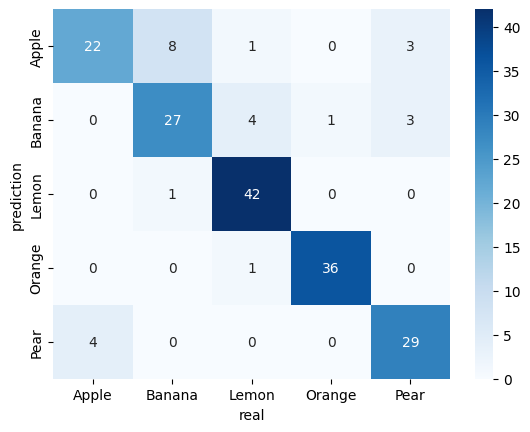

In [132]:
y_train = ids2labels(dataset["train"]["label"])
y_pred_raw = upgrated_model.predict(
    dataset["train"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_train, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_train, y_pred=y_pred)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step
{'accuracy': 0.8478260869565217,
 'f1': {'Apple': np.float64(0.8571428571428571),
        'Banana': np.float64(0.75),
        'Lemon': np.float64(0.8421052631578947),
        'Orange': np.float64(1.0),
        'Pear': np.float64(0.8)},
 'precision': {'Apple': np.float64(0.8571428571428571),
               'Banana': np.float64(0.75),
               'Lemon': np.float64(0.8),
               'Orange': np.float64(1.0),
               'Pear': np.float64(0.8571428571428571)},
 'recall': {'Apple': np.float64(0.8571428571428571),
            'Banana': np.float64(0.75),
            'Lemon': np.float64(0.8888888888888888),
            'Orange': np.float64(1.0),
            'Pear': np.float64(0.75)}}


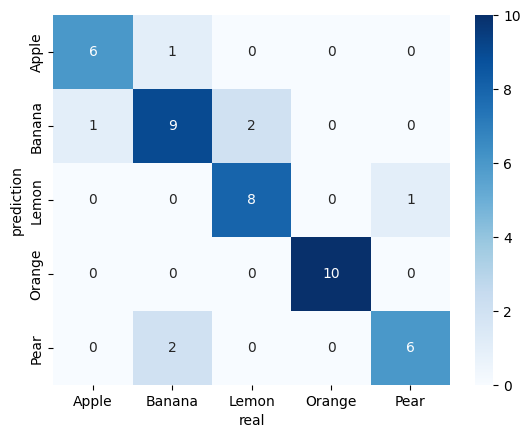

In [133]:
y_val = ids2labels(dataset["validation"]["label"])
y_pred_raw = upgrated_model.predict(
    dataset["validation"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_val, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_val, y_pred=y_pred)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 487ms/step
{'accuracy': 0.8275862068965517,
 'f1': {'Apple': np.float64(0.6),
        'Banana': np.float64(0.782608695652174),
        'Lemon': np.float64(1.0),
        'Orange': np.float64(1.0),
        'Pear': np.float64(0.7741935483870968)},
 'precision': {'Apple': np.float64(0.6),
               'Banana': np.float64(0.75),
               'Lemon': np.float64(1.0),
               'Orange': np.float64(1.0),
               'Pear': np.float64(0.8)},
 'recall': {'Apple': np.float64(0.6),
            'Banana': np.float64(0.8181818181818182),
            'Lemon': np.float64(1.0),
            'Orange': np.float64(1.0),
            'Pear': np.float64(0.75)}}


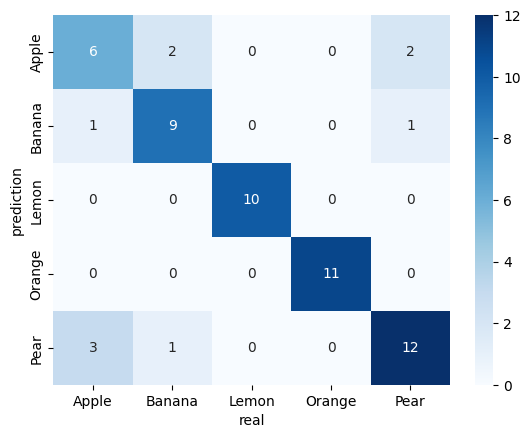

In [134]:
y_test = ids2labels(dataset["test"]["label"])
y_pred_raw = upgrated_model.predict(
    dataset["test"]
    .to_tf_dataset(
        batch_size=40,
        columns=["image"],
        shuffle=False
    )
)
y_pred = ids2labels(tf_preds2ids(y_pred_raw))
pprint(calc_test_metrics(y_true=y_test, y_pred=y_pred), width=1, )
show_confusion_matrix_plot(y_true=y_test, y_pred=y_pred)

After a deep research and testing these might be one of the best results we could get. Overfitting was reduced, keeping the accuracy values between 0.82 and 0.85, which are also good general results. However we still can notice that the model has problem classifying apples. The most probable source of this issue is that the dataset has green and red apple mixed together, which confuse the model during training.

Normally this can be fixed by increasing the number of training examples. This can be achieved by increasing the original dataset or applying data augmentation techniques. `Tensorflow` provide several data augmentation tool apart from the already used, however the model has trouble training with that. Might be because of the low image quality, that applying data augmentation change radically the images or just that there aren't enough true examples (images of different individuals). Because of this, it might be a good shot to try by increasing the number of examples in the dataset if we want to keep improving the model.

# Saving best model

We serialize the model that we want to use for production.

In [136]:
_model_dir_path = os.path.join("./models")

upgrated_model.save(os.path.join(_model_dir_path, "fruit_classifier.keras"))